In [1]:
# === Imports
from __future__ import annotations
import os, glob, datetime as dt
import numpy as np
import pandas as pd
import geopandas as gpd
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
from shapely.geometry import box

In [2]:
# === Paths & config
GPKG_DIR   = "/home/ksarna/qkrig"
EXPORT_DIR = "/home/ksarna/Documents/qkrig/exports"  # 120 NPZ/NC files Sep 24-28
OUTPUT_DIR = "/home/ksarna/qkrig/output"
REF_DIR    = "/home/ksarna/qkrig/gage-03463300"

LAYER    = "divides"
ID_FIELD = "divide_id"

GAGES = [
    "gage-02138500",
    "gage-03441000",
    "gage-0344894205",
    "gage-03456100",
    "gage-03463300",
    "gage-03479000",
]

import datetime as dt
HOUR_START = dt.datetime(2024, 9, 25,  0)
HOUR_END   = dt.datetime(2024, 9, 28, 23)

In [3]:
# === Load all gpkg files and compute WGS84 centroids
import geopandas as gpd, pandas as pd, os

gdfs = {}
for gage in GAGES:
    path = os.path.join(GPKG_DIR, f"{gage}_subset.gpkg")
    gdf = gpd.read_file(path, layer=LAYER)
    gdf_proj = gdf if not gdf.crs.is_geographic else gdf.to_crs("EPSG:5070")
    gdf["centroid"] = gpd.GeoSeries(gdf_proj.geometry.centroid, crs=gdf_proj.crs).to_crs(4326)
    gdfs[gage] = gdf
    print(f"{gage}: {len(gdf)} catchments — {gdf[ID_FIELD].tolist()[:3]}")

print(f"\nTotal gages: {len(gdfs)}")

gage-02138500: 19 catchments — ['cat-261831', 'cat-261836', 'cat-261837']
gage-03441000: 14 catchments — ['cat-1017087', 'cat-1017086', 'cat-1017088']
gage-0344894205: 2 catchments — ['cat-1016892', 'cat-1016900']
gage-03456100: 20 catchments — ['cat-1016593', 'cat-1016462', 'cat-1016463']
gage-03463300: 21 catchments — ['cat-1016279', 'cat-1016280', 'cat-1016281']
gage-03479000: 31 catchments — ['cat-1017689', 'cat-1017690', 'cat-1017691']

Total gages: 6


In [4]:
# === Inspect one export file to confirm structure
import os, numpy as np, xarray as xr

def export_path_for_hour(ts):
    base = os.path.join(EXPORT_DIR, f"interp_{ts.strftime('%Y-%m-%d_%H')}")
    for ext in (".nc", ".npz"):
        if os.path.exists(base + ext):
            return base + ext
    return None

example = None
cur = HOUR_START
while cur <= HOUR_END:
    p = export_path_for_hour(cur)
    if p:
        example = p
        break
    cur += dt.timedelta(hours=1)

if example is None:
    raise FileNotFoundError(f"No export files found in {EXPORT_DIR} for the given range.")

print(f"Example file: {example}")
if example.endswith(".nc"):
    with xr.open_dataset(example) as ds:
        print("Format: NetCDF")
        print("Variables:", list(ds.data_vars))
        print("Attrs:", ds.attrs)
        print("z_interp shape:", ds["z_interp"].shape)
else:
    with np.load(example, allow_pickle=True) as z:
        print("Format: NPZ")
        print("Keys:", list(z.files))
        print("z_interp shape:", z["z_interp"].shape)
        print("grid_lon shape:", z["grid_lon"].shape)

Example file: /home/ksarna/Documents/qkrig/exports/interp_2024-09-25_00.npz
Format: NPZ
Keys: ['grid_lon', 'grid_lat', 'z_interp', 'kriging_variance', 'meta_date', 'meta_variogram_model', 'meta_grid_size']
z_interp shape: (100, 100)
grid_lon shape: (100,)


In [5]:
# === Build hourly time series per gage (supports both .nc and .npz)
import numpy as np, xarray as xr, pandas as pd

def nearest_grid_value(lons, lats, vals, pt_lon, pt_lat):
    ix = np.argmin(np.abs(lons - pt_lon))
    iy = np.argmin(np.abs(lats - pt_lat))
    v = float(vals[iy, ix])
    return v if np.isfinite(v) else np.nan

def load_export(path):
    """Load (lons, lats, z_mm_hr) from .nc or .npz. Converts mm/day -> mm/hr."""
    if path.endswith(".nc"):
        with xr.open_dataset(path) as ds:
            return ds["lon"].values.copy(), ds["lat"].values.copy(), (ds["z_interp"].values / 24.0).copy()
    else:
        with np.load(path, allow_pickle=True) as z:
            return z["grid_lon"].copy(), z["grid_lat"].copy(), (z["z_interp"] / 24.0).copy()

hours = []
cur = HOUR_START
while cur <= HOUR_END:
    hours.append(cur)
    cur += dt.timedelta(hours=1)

# Load all available export files once (shared across all gages)
nc_cache = {}
missing = 0
for ts in hours:
    p = export_path_for_hour(ts)
    if p:
        nc_cache[ts] = load_export(p)
    else:
        missing += 1

print(f"Files loaded: {len(nc_cache)} / {len(hours)} hours  ({missing} missing)")

# Build TS per gage
TS_ALL = {}
for gage, gdf in gdfs.items():
    divide_ids = gdf[ID_FIELD].values
    TS = pd.DataFrame(index=pd.DatetimeIndex(hours), columns=divide_ids, dtype=float)
    for ts, (lons, lats, z) in nc_cache.items():
        ser = gdf["centroid"].apply(lambda pt: nearest_grid_value(lons, lats, z, pt.x, pt.y))
        TS.loc[ts, :] = ser.values
    TS_ALL[gage] = TS
    print(f"  {gage}: {TS.notna().any(axis=1).sum()} hours × {len(divide_ids)} catchments")

print("\nDone.")

Files loaded: 96 / 96 hours  (0 missing)
  gage-02138500: 96 hours × 19 catchments
  gage-03441000: 96 hours × 14 catchments
  gage-0344894205: 96 hours × 2 catchments
  gage-03456100: 96 hours × 20 catchments
  gage-03463300: 96 hours × 21 catchments
  gage-03479000: 96 hours × 31 catchments

Done.


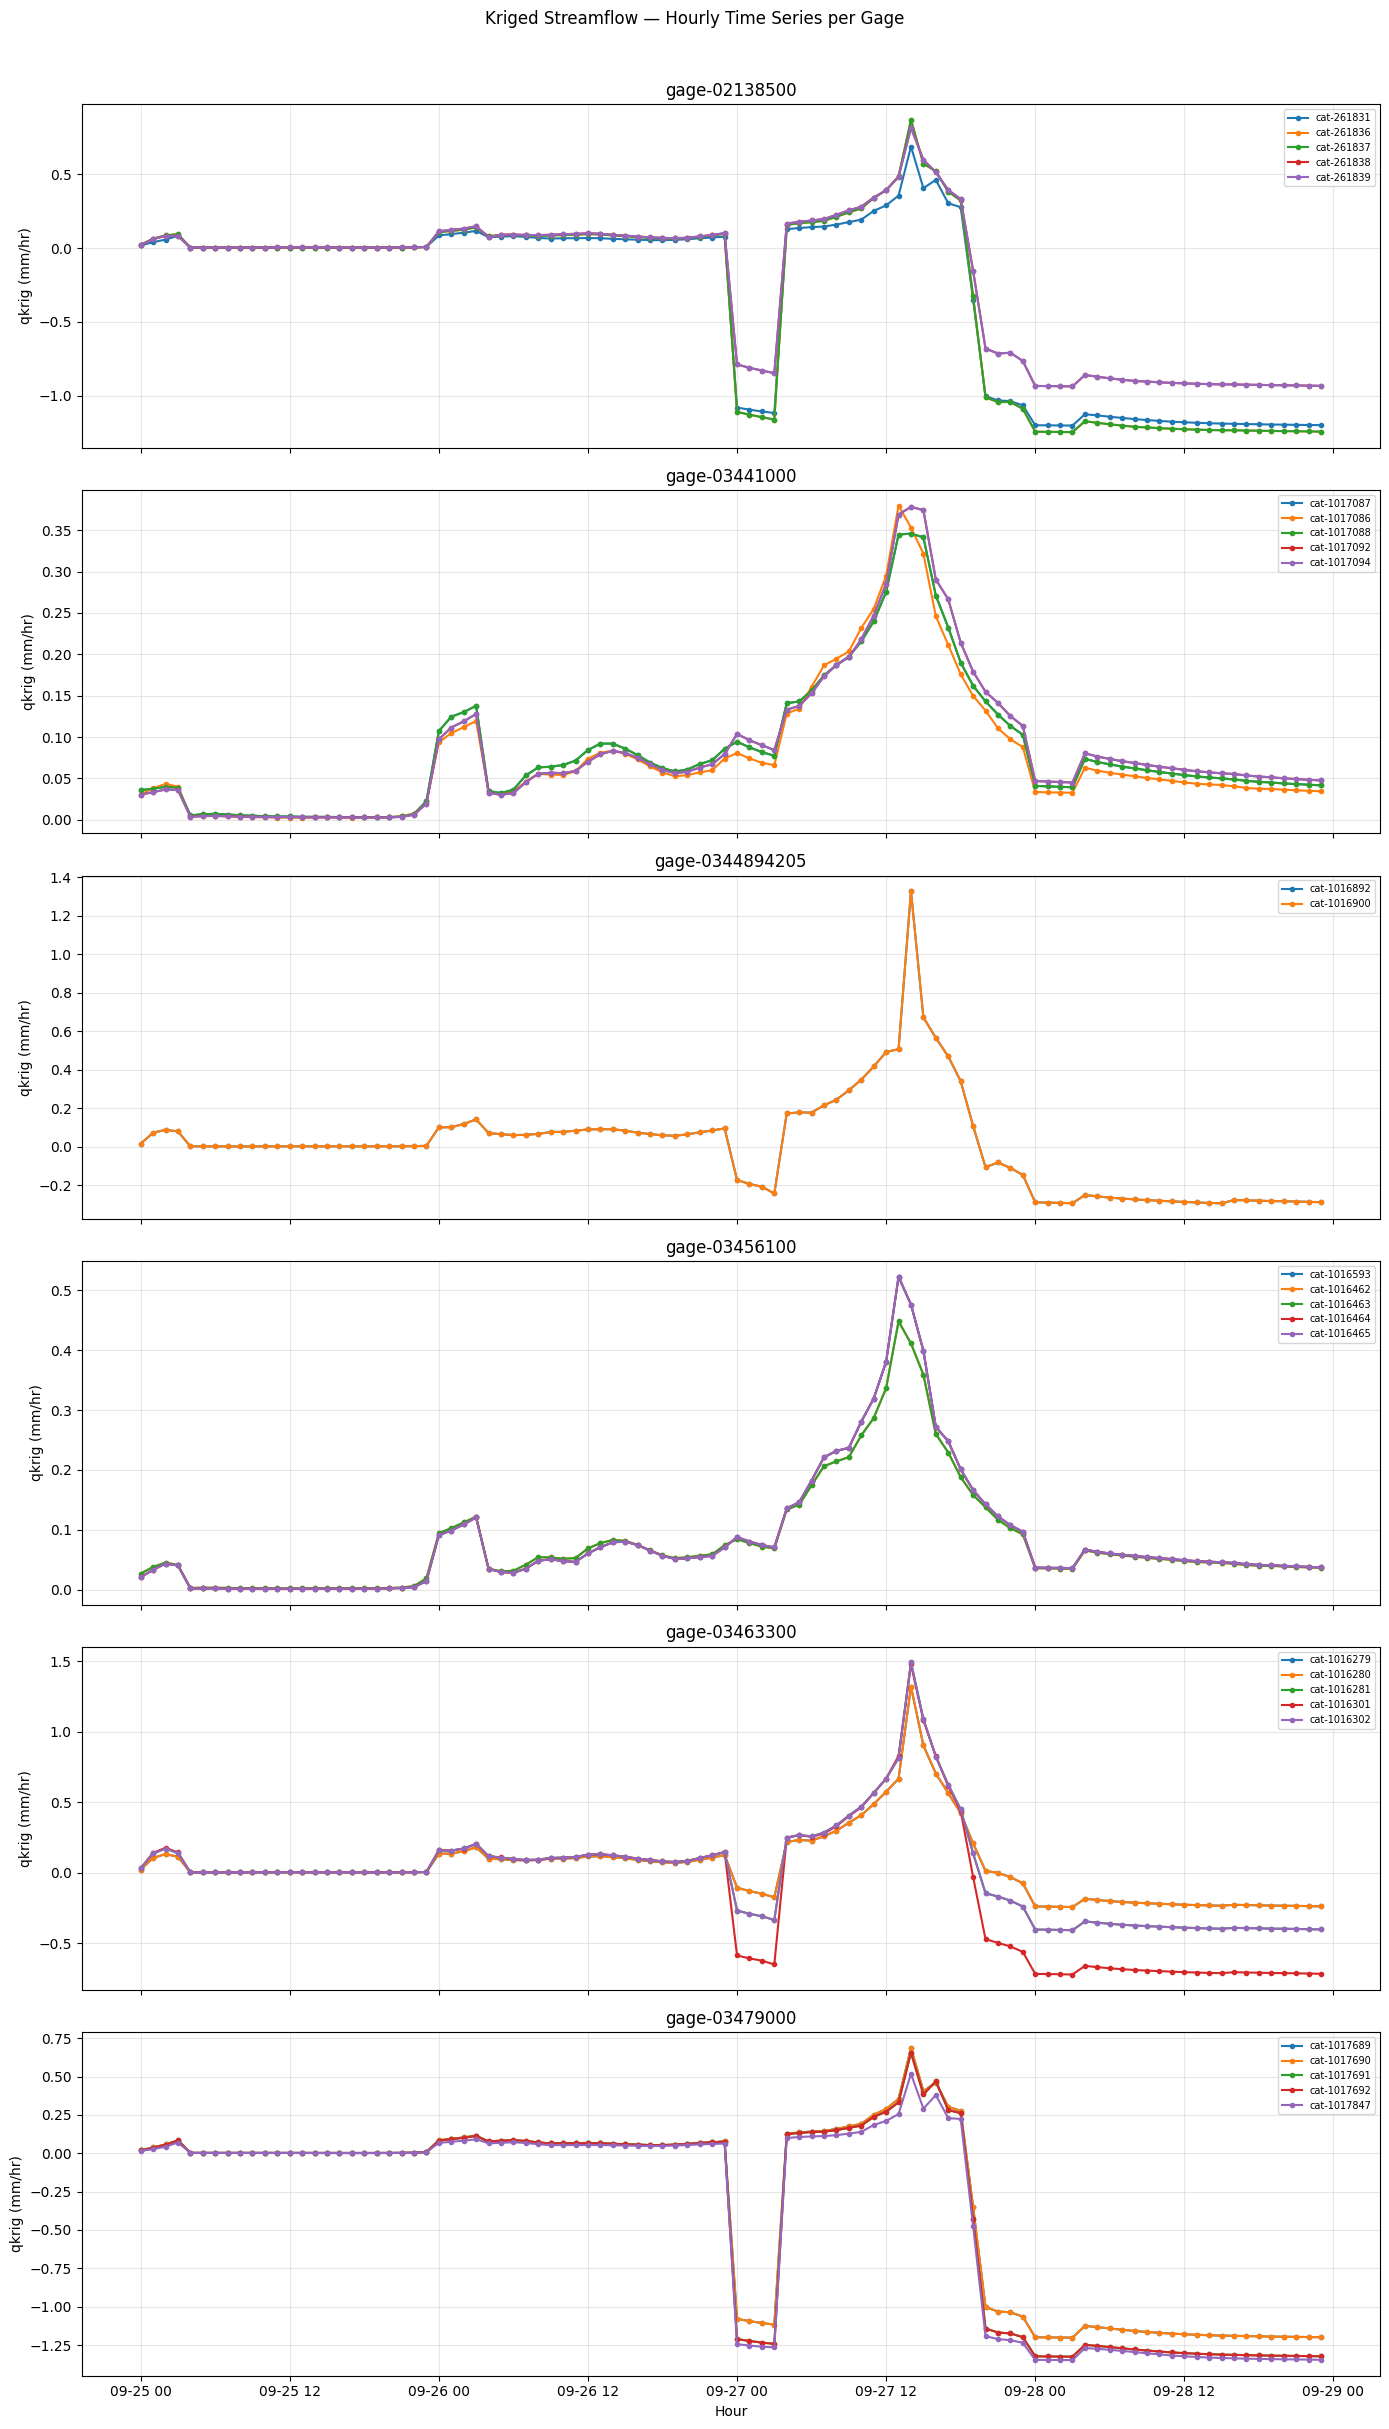

In [6]:
# === Plot hourly time series — one subplot per gage
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(GAGES), 1, figsize=(14, 4 * len(GAGES)), sharex=True)
if len(GAGES) == 1:
    axes = [axes]

for ax, gage in zip(axes, GAGES):
    TS = TS_ALL[gage]
    for col in TS.columns[:5]:
        ax.plot(TS.index, TS[col], marker="o", markersize=3, label=col)
    ax.set_title(gage)
    ax.set_ylabel("qkrig (mm/hr)")
    ax.legend(fontsize=7, loc="upper right")
    ax.grid(True, alpha=0.3)

axes[-1].set_xlabel("Hour")
plt.suptitle("Kriged Streamflow — Hourly Time Series per Gage", y=1.01)
plt.tight_layout()
plt.show()

In [7]:
# === Summary stats per catchment across all hours
stats_all = {}
for gage, TS in TS_ALL.items():
    stats_all[gage] = pd.DataFrame({
        "mean": TS.mean(),
        "min":  TS.min(),
        "max":  TS.max(),
        "std":  TS.std(),
    })
    print(f"\n--- {gage} ---")
    print(stats_all[gage].to_string())


--- gage-02138500 ---
                mean       min       max       std
cat-261831 -0.324144 -1.201905  0.687307  0.599888
cat-261836 -0.320116 -1.246432  0.867512  0.636871
cat-261837 -0.320116 -1.246432  0.867512  0.636871
cat-261838 -0.212262 -0.936608  0.814439  0.494111
cat-261839 -0.212262 -0.936608  0.814439  0.494111
cat-261840 -0.117808 -0.656054  0.729674  0.364367
cat-261841 -0.044776 -0.422187  0.607810  0.254137
cat-261853 -0.320116 -1.246432  0.867512  0.636871
cat-261856 -0.535991 -1.852492  0.936415  0.916632
cat-261852 -0.431708 -1.561514  0.903438  0.782205
cat-261855 -0.263829 -1.027810  0.661844  0.518403
cat-261832 -0.263827 -1.027810  0.661844  0.518404
cat-261833 -0.431708 -1.561514  0.903438  0.782205
cat-261834 -0.431708 -1.561514  0.903438  0.782205
cat-261857 -0.431708 -1.561514  0.903438  0.782205
cat-261835 -0.320116 -1.246432  0.867512  0.636871
cat-261854 -0.431708 -1.561514  0.903438  0.782205
cat-261851 -0.320116 -1.246432  0.867512  0.636871
cat-2618

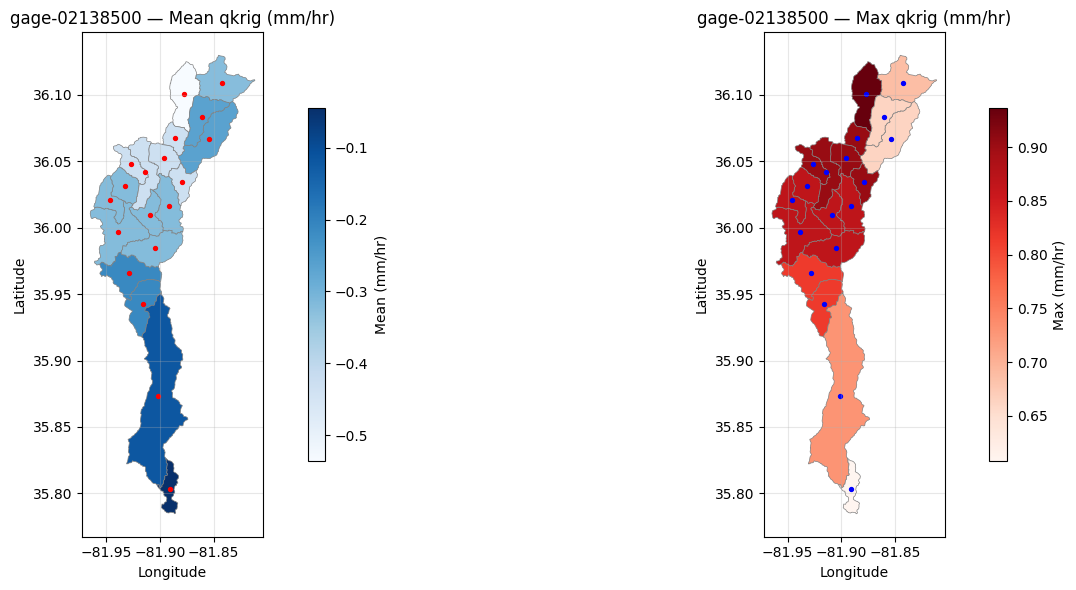

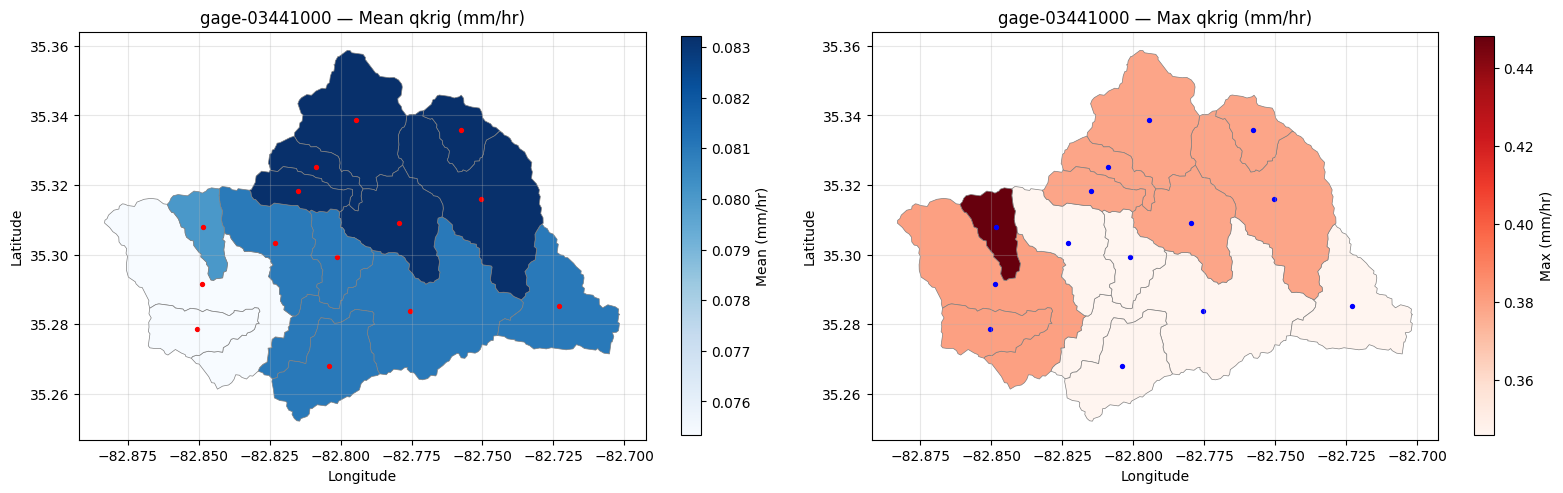

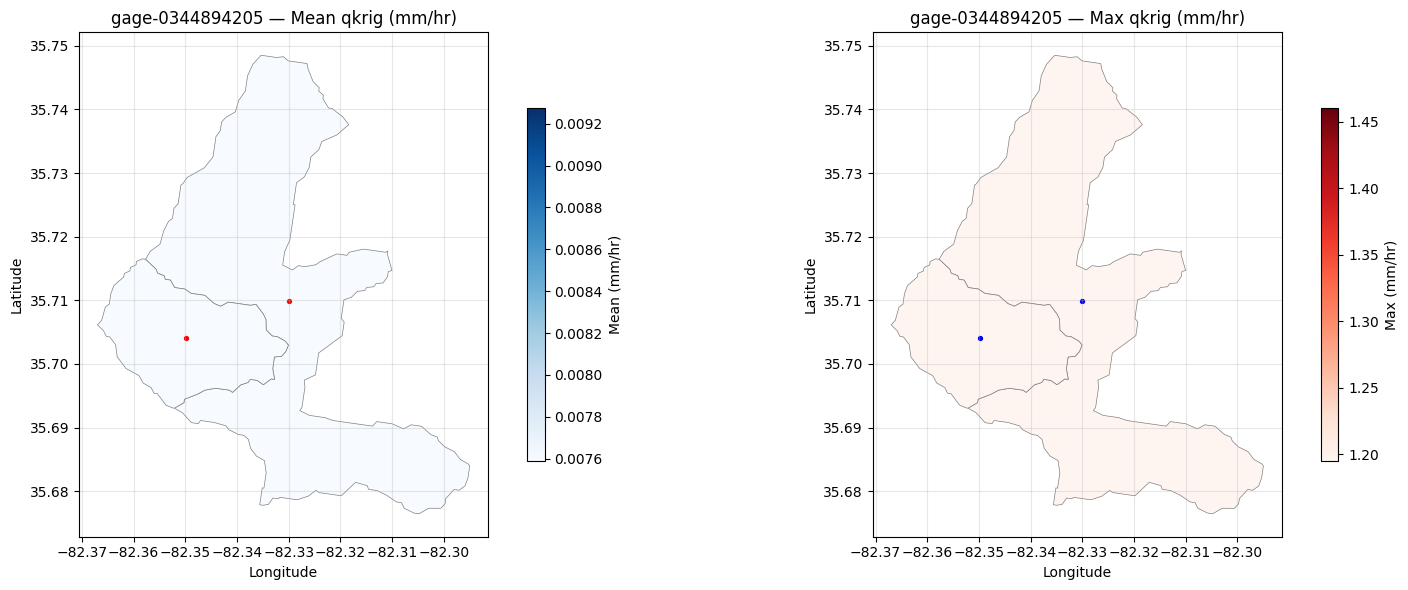

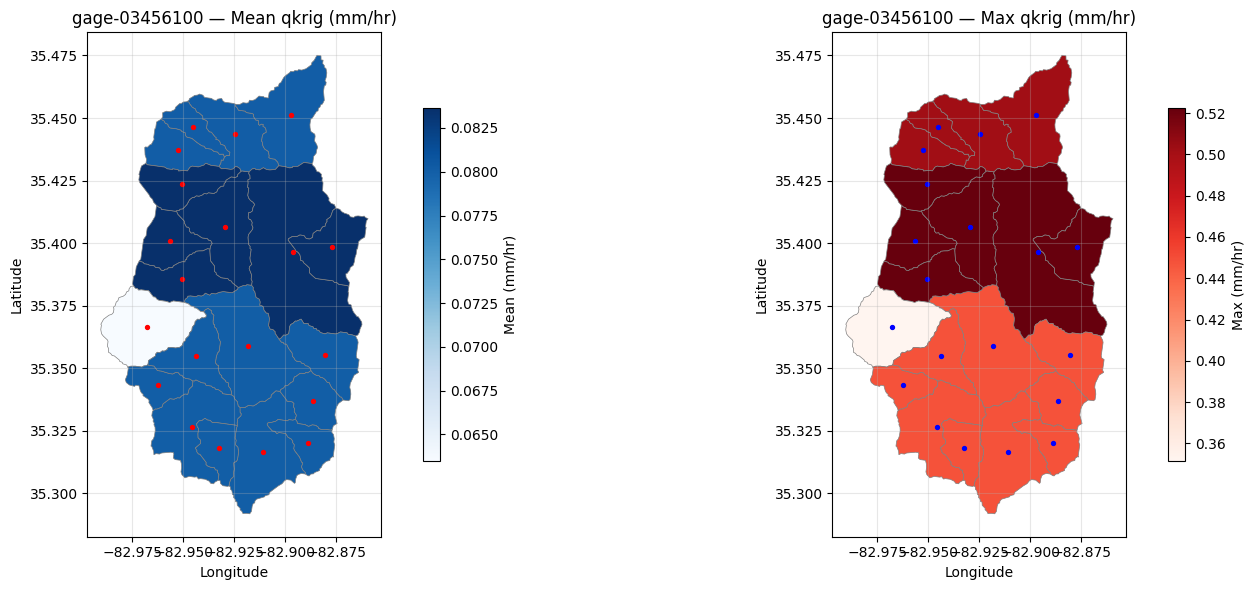

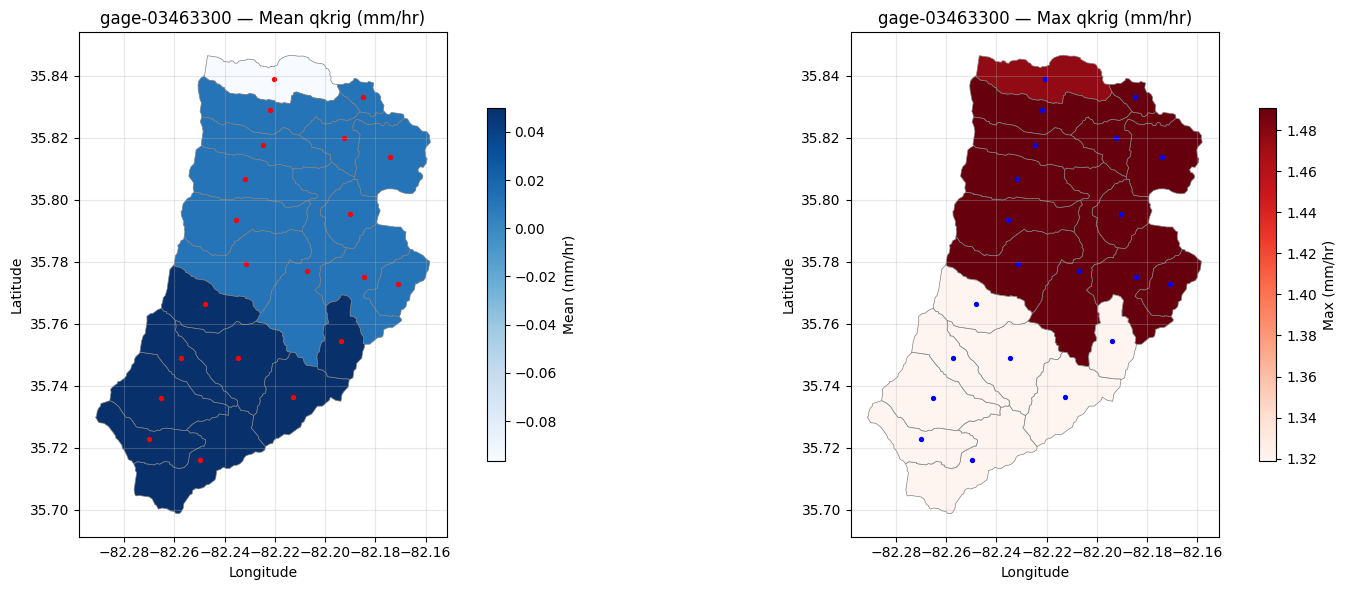

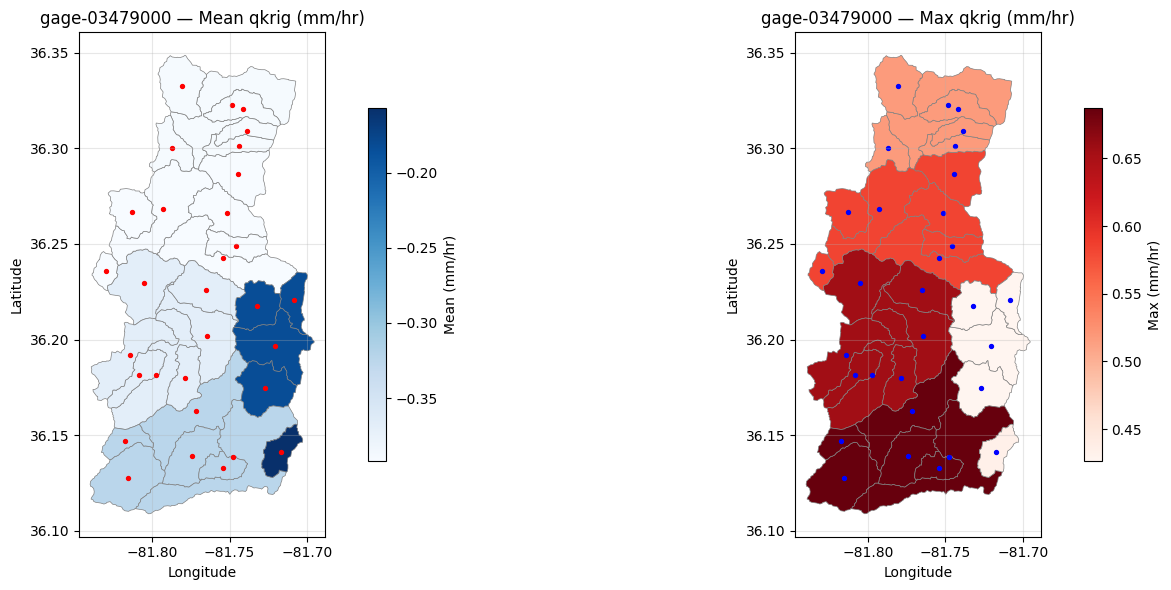

In [8]:
# === Per-gage catchment map colored by mean kriged value
import matplotlib as mpl

for gage in GAGES:
    gdf   = gdfs[gage]
    stats = stats_all[gage]

    gdf["mean_qkrig"] = gdf[ID_FIELD].map(stats["mean"])
    gdf["max_qkrig"]  = gdf[ID_FIELD].map(stats["max"])

    gdf_wgs84 = gdf.to_crs(4326)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Mean map
    gdf_wgs84.plot(
        ax=axes[0], column="mean_qkrig", cmap="Blues", legend=True,
        legend_kwds={"label": "Mean (mm/hr)", "shrink": 0.7},
        edgecolor="grey", linewidth=0.5,
        missing_kwds={"color": "lightgrey"},
    )
    gdf_wgs84.set_geometry("centroid").plot(ax=axes[0], color="red", markersize=8)
    axes[0].set_title(f"{gage} — Mean qkrig (mm/hr)")
    axes[0].set_xlabel("Longitude"); axes[0].set_ylabel("Latitude")
    axes[0].grid(True, alpha=0.3)

    # Max map
    gdf_wgs84.plot(
        ax=axes[1], column="max_qkrig", cmap="Reds", legend=True,
        legend_kwds={"label": "Max (mm/hr)", "shrink": 0.7},
        edgecolor="grey", linewidth=0.5,
        missing_kwds={"color": "lightgrey"},
    )
    gdf_wgs84.set_geometry("centroid").plot(ax=axes[1], color="blue", markersize=8)
    axes[1].set_title(f"{gage} — Max qkrig (mm/hr)")
    axes[1].set_xlabel("Longitude"); axes[1].set_ylabel("Latitude")
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

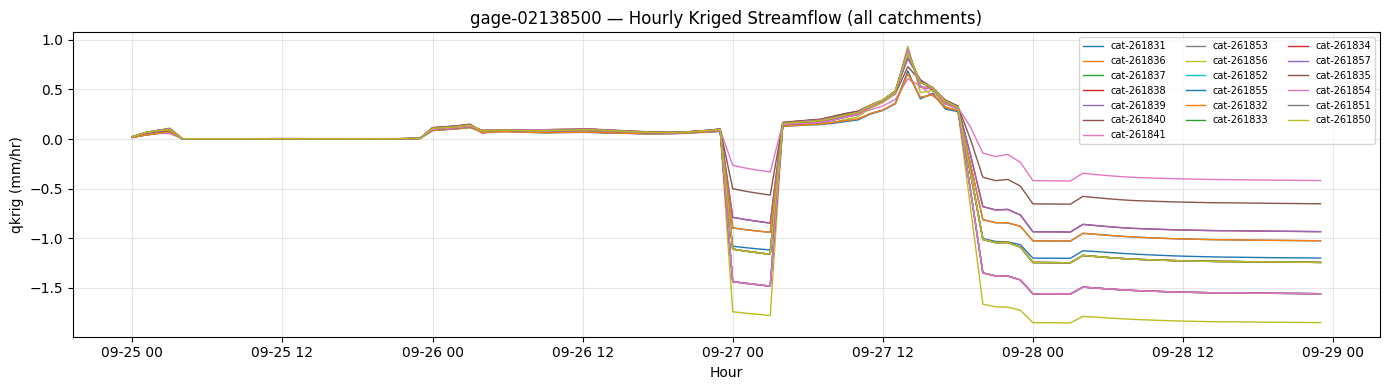

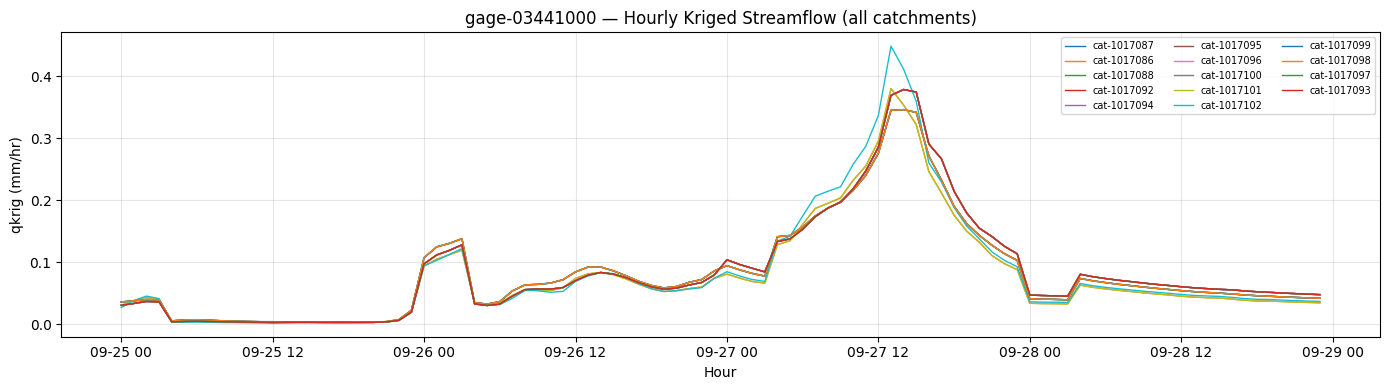

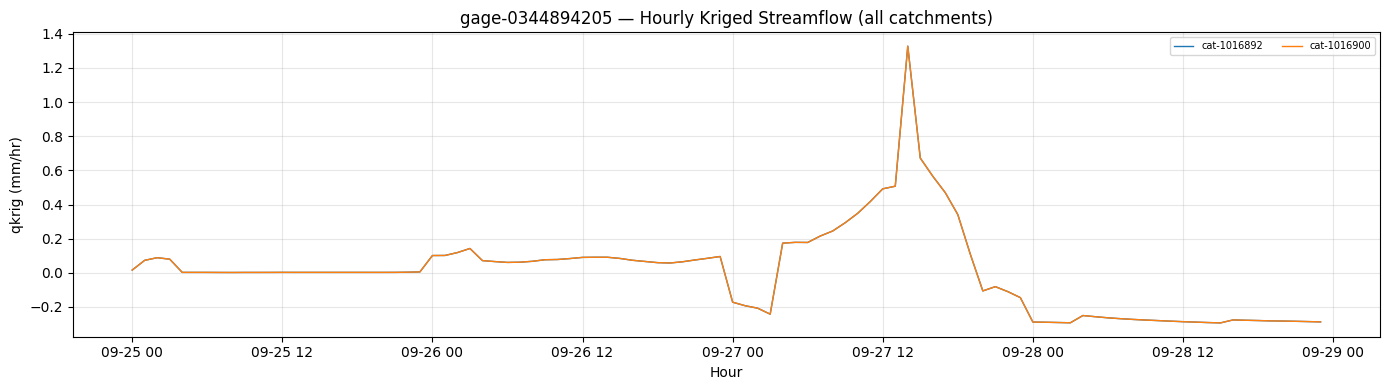

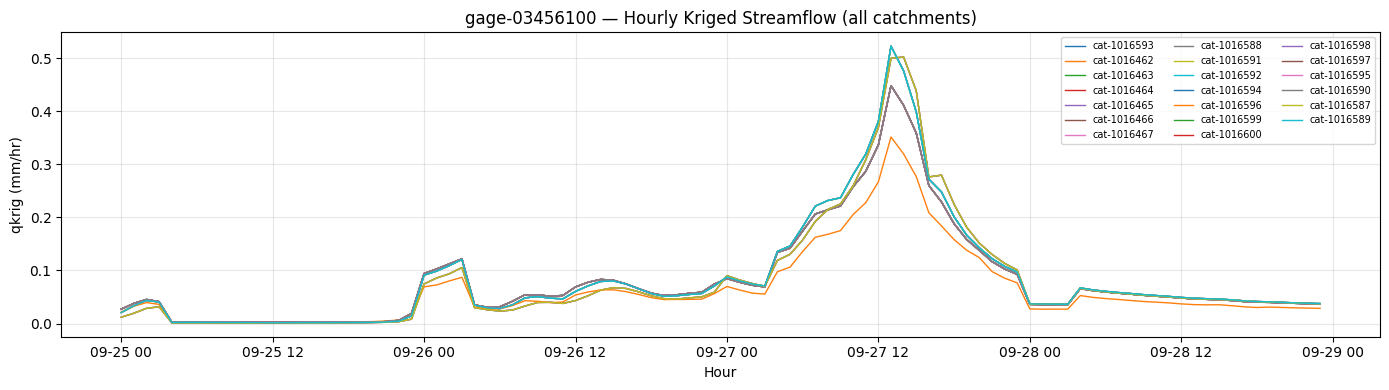

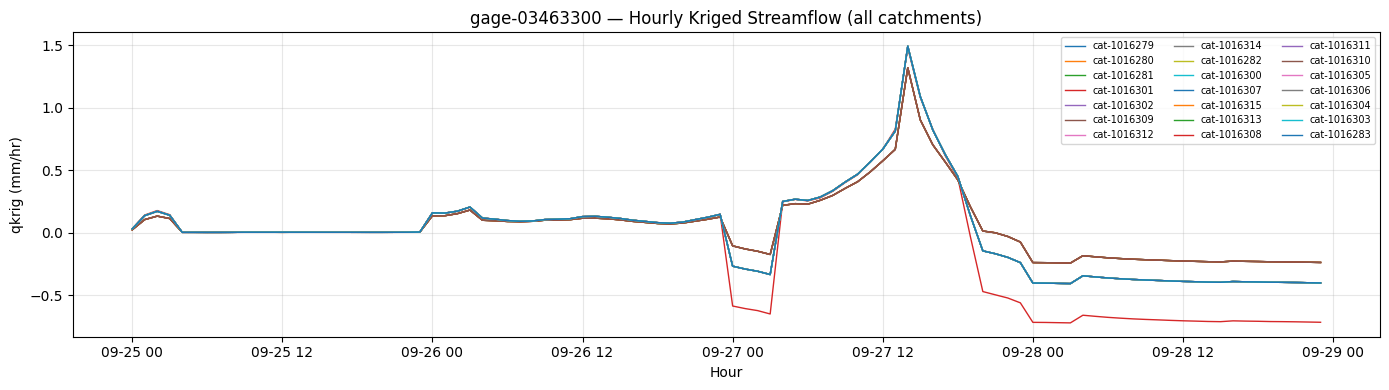

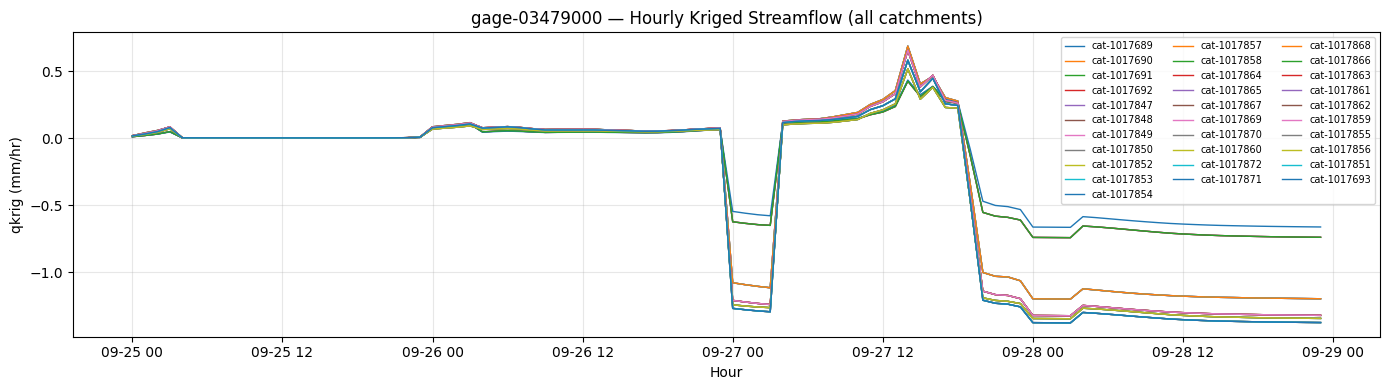

In [9]:
# === Per-gage hourly time series (all catchments per gage)
for gage in GAGES:
    TS = TS_ALL[gage]

    fig, ax = plt.subplots(figsize=(14, 4))
    for col in TS.columns:
        ax.plot(TS.index, TS[col], linewidth=1, label=col)

    ax.set_title(f"{gage} — Hourly Kriged Streamflow (all catchments)")
    ax.set_xlabel("Hour")
    ax.set_ylabel("qkrig (mm/hr)")
    ax.legend(fontsize=7, loc="upper right", ncol=3)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

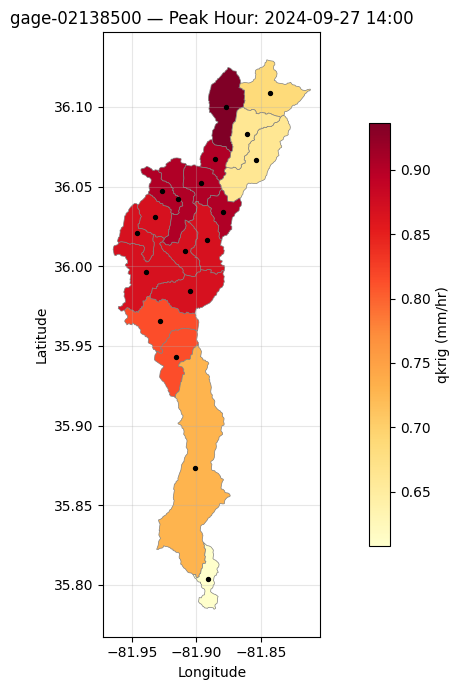

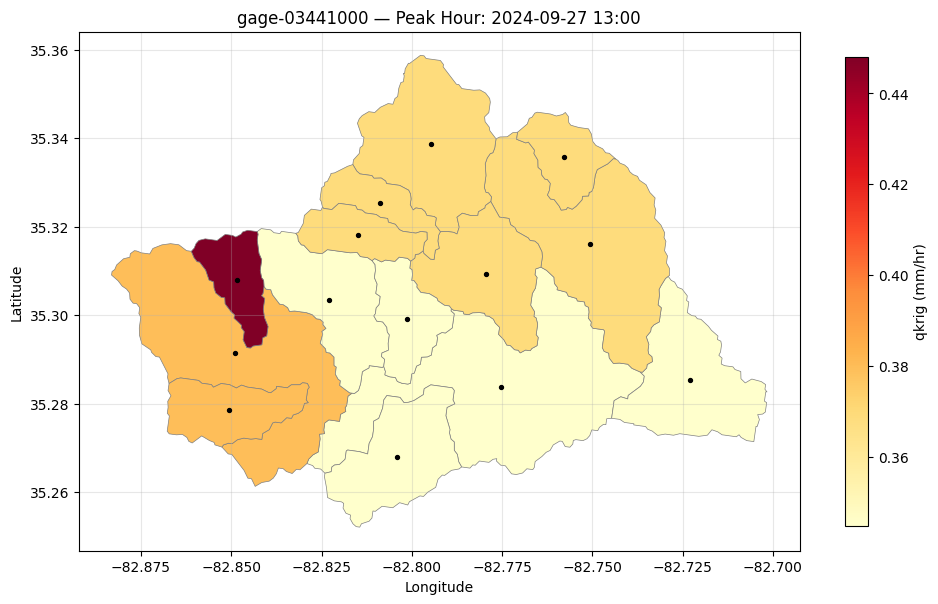

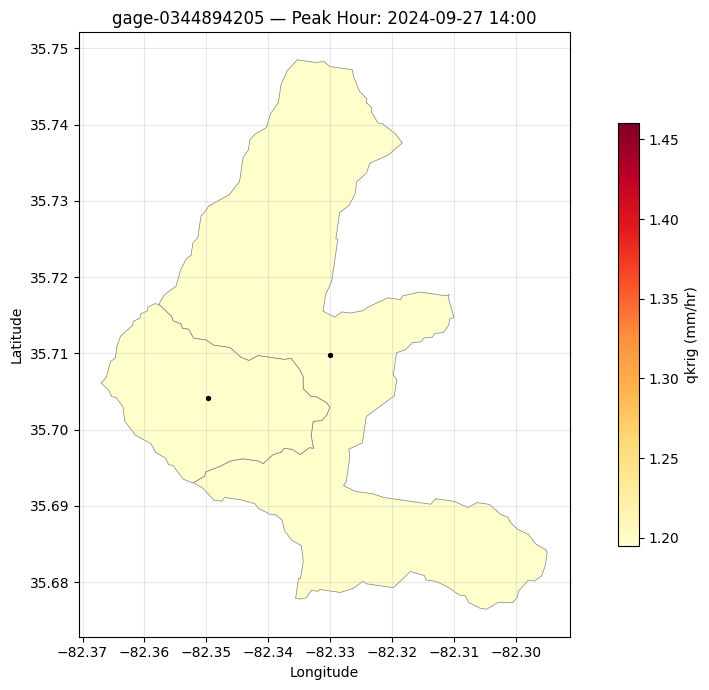

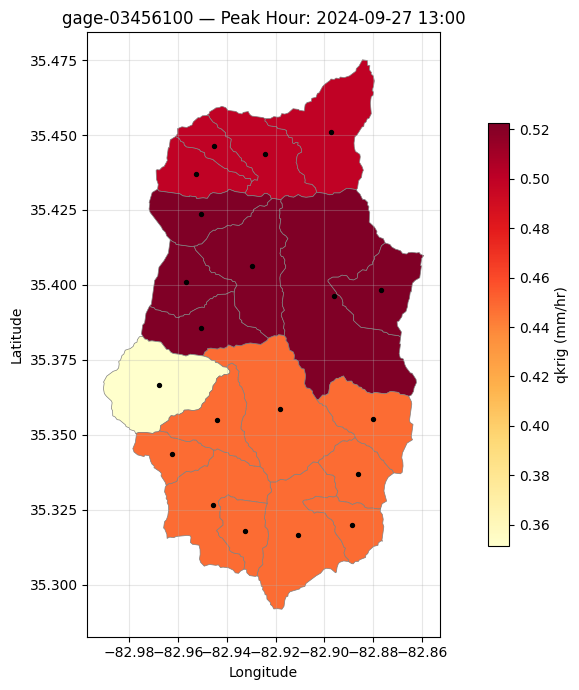

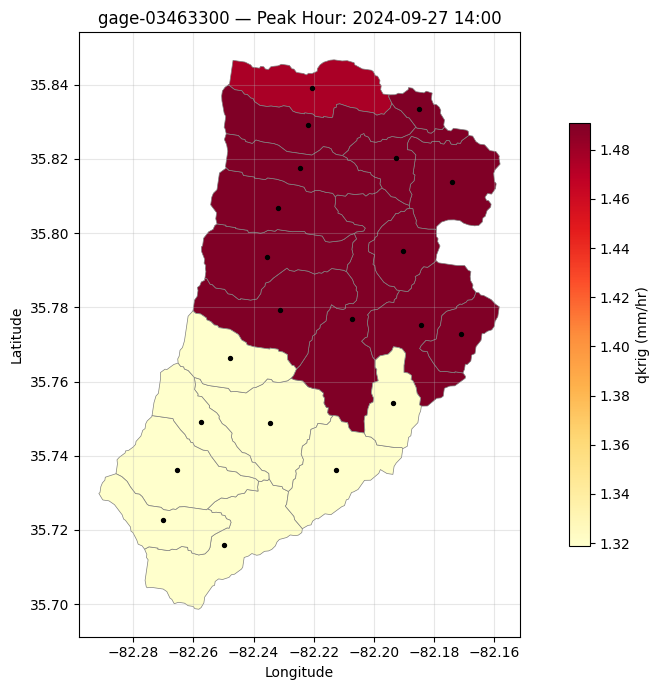

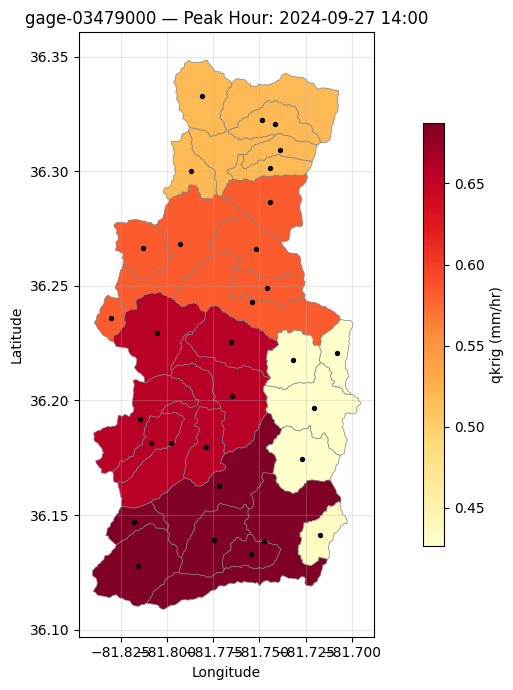

In [10]:
# === Peak hour map — show catchments colored by value at the hour with highest mean flow
for gage in GAGES:
    TS   = TS_ALL[gage]
    gdf  = gdfs[gage]

    peak_hour = TS.mean(axis=1).idxmax()
    peak_vals = TS.loc[peak_hour]

    gdf["peak_qkrig"] = gdf[ID_FIELD].map(peak_vals)
    gdf_wgs84 = gdf.to_crs(4326)

    fig, ax = plt.subplots(figsize=(10, 7))
    gdf_wgs84.plot(
        ax=ax, column="peak_qkrig", cmap="YlOrRd", legend=True,
        legend_kwds={"label": "qkrig (mm/hr)", "shrink": 0.7},
        edgecolor="grey", linewidth=0.5,
        missing_kwds={"color": "lightgrey"},
    )
    gdf_wgs84.set_geometry("centroid").plot(ax=ax, color="black", markersize=8, zorder=5)

    ax.set_title(f"{gage} — Peak Hour: {peak_hour.strftime('%Y-%m-%d %H:00')}")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [ ]:
# === Spatial plots at multiple timesteps per gage
# TIMESTEP_STRIDE: plot every N hours (e.g. 6 = four snapshots per day)
TIMESTEP_STRIDE = 6

for gage in GAGES:
    TS  = TS_ALL[gage]
    gdf = gdfs[gage]

    # Select evenly-spaced timesteps that have data
    valid_hours = [h for h in TS.index if TS.loc[h].notna().any()]
    snap_hours  = valid_hours[::TIMESTEP_STRIDE]

    n     = len(snap_hours)
    ncols = 4
    nrows = (n + ncols - 1) // ncols

    # Shared color scale across all timesteps for this gage
    vmin = float(TS.min().min())
    vmax = float(TS.max().max())

    gdf_wgs84 = gdf.to_crs(4326)

    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
    axes = axes.flatten() if nrows > 1 else list(axes) if n > 1 else [axes]

    for i, ts in enumerate(snap_hours):
        ax  = axes[i]
        vals = TS.loc[ts]
        gdf_wgs84["qkrig"] = gdf_wgs84[ID_FIELD].map(vals)

        gdf_wgs84.plot(
            ax=ax, column="qkrig", cmap="YlOrRd",
            vmin=vmin, vmax=vmax,
            edgecolor="grey", linewidth=0.4,
            missing_kwds={"color": "lightgrey"},
            legend=False,
        )
        gdf_wgs84.set_geometry("centroid").plot(ax=ax, color="black", markersize=4, zorder=5)
        ax.set_title(ts.strftime("%Y-%m-%d %H:00"), fontsize=9)
        ax.set_xlabel("Lon", fontsize=7); ax.set_ylabel("Lat", fontsize=7)
        ax.tick_params(labelsize=6)
        ax.grid(True, alpha=0.3)

    # Hide unused axes
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Shared colorbar
    sm = plt.cm.ScalarMappable(cmap="YlOrRd", norm=plt.Normalize(vmin=vmin, vmax=vmax))
    sm._A = []
    cbar = fig.colorbar(sm, ax=axes[:i+1], fraction=0.02, pad=0.04)
    cbar.set_label("qkrig (mm/hr)", fontsize=9)

    fig.suptitle(f"{gage} — Spatial Snapshots (every {TIMESTEP_STRIDE}h)", fontsize=12, y=1.01)
    plt.tight_layout()
    plt.show()